# Data Mining 2026  — Project Notebook

**Course:** Data Mining  
**Project track:** Standard Analysis 
**Group members:**  
- Augustas Butenas
- Adrian Nathanael Christantyo
- Ana-Maria Rusnac
- Bora Tarlan

**Dataset:**  <br>
The dataset to be explored in this project is the Gowalla dataset, found at the [source](https://snap.stanford.edu/data/loc-Gowalla.html). Gowalla is a location-based social networking website where users built friendship networks and shared their locations through check-ins. The friendship network is represented by an undirected graph, consisting of 196,591 nodes and 950,327 edges. Additionally, it includes 6,442,890 check-ins made by users withing the period Feb 2009 - Oct 2010. Each check-in contains spatial and temporal information.

**Initial task description (Module 1 perspective):** <br>
Before applying any algorithms the validity of the data must be checked. For further analysis it might be useful to know if the friendship graph is connected \ find the connected subgraphs. Secondly, a map of the coordinates can be created. With this it easy to see some outlier check-ins. Secondly, we'd see how large the area of observation is. If it is large enough it might be a good idea to find observation clusters, and in that way we can avoid accounting for the "looping" of coordinates. Furthermore, in order to catch some nonsense data a couple of things can be done: 1. for same location IDs check if the coordinates are similar; 2. For same person check ins that are near in time does it seem that seem like they teleported.
 
In the context of clustering, some of the main tasks would be hierarchical and subspace clustering of user check-in locations. The goal is to provide an analysis on spatial behaviour at multiple scales, for example multiple clusters could represent a street, a neighbourhood, or a city. Based on these scales behaviours can be compared as well, most importantly if different users or communities are similar in distinct subspaces. 

Another point would be hierarchical friend groups, groups at different scales may correspond to one-off meetings, distant friends to close friends and family. Thus, inference of relationships could also be accomplished, the frequency of 2 people checking in at the same time might suggest social ties. Using the same train of thought, the model could even suggest possible friendships if 2 people meeting frequently or occasionally are not already friends according to the graph.

A second focus point would be community detection and sequence segmentation and similarities. The goal is to identify groups of users that are densely connected and analyse if there are mobility patterns based on check in locations. In this case, user check ins are treated as temporal movement sequences. Multiple interesting questions can be explored, such as if the behaviour similarity is based on movement sequence rather than relation and which are the most common routes.

Lastly, a potential focus could be location labeling based on visiting frequency and time, for example, a place that is visited very often by a single person can be labeled as a home location. On the other hand, a place that is primarily visited in the evening by groups of friends might be labeled as night-leisure location. 


## 0. Reproducibility and Setup

In [3]:

import sys
print(sys.version)

import pandas as pd
import numpy as np
import seaborn as sns            
import matplotlib.pyplot as plt
from shapely.geometry import Point
import geopandas as gpd
from pathlib import Path
import reverse_geocoder as rg
import country_converter as coco
from tabulate import tabulate
from pygal_maps_world.maps import World
from IPython.display import SVG
from sklearn.cluster import DBSCAN
import hdbscan
from sklearn.cluster import OPTICS
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import haversine_distances
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


## 1. Dataset Description and Loading

### 1.1 Dataset Overview

- Source: The dataset is the Gowalla location-based social networking dataset collected by Stanford Network Analysis Project (SNAP).
- Number of instances: There are 6.442.892 instances and 6.442.291 unique instances.
- Number of features / entities: There are 5 columns, the user ID, check-in time, latitude, longitude, and location ID.
- Missing values: There are no missing values in the dataset


In [2]:
# Load dataset
BASE_DIR = Path().resolve()
file_path = BASE_DIR / "data" / "loc-gowalla_totalCheckins.txt"

df = pd.read_csv(file_path, sep = "\t", header = None, names=["user_id", "checkin_time", "latitude", "longitude", "location_id"])

print(df.head(5))
print(df.tail(5))
print(df.dtypes)

   user_id          checkin_time   latitude  longitude  location_id
0        0  2010-10-19T23:55:27Z  30.235909 -97.795140        22847
1        0  2010-10-18T22:17:43Z  30.269103 -97.749395       420315
2        0  2010-10-17T23:42:03Z  30.255731 -97.763386       316637
3        0  2010-10-17T19:26:05Z  30.263418 -97.757597        16516
4        0  2010-10-16T18:50:42Z  30.274292 -97.740523      5535878
         user_id          checkin_time   latitude  longitude  location_id
6442887   196578  2010-06-11T13:32:26Z  51.742988  -0.488065       906885
6442888   196578  2010-06-11T13:26:45Z  51.746492  -0.490780       965121
6442889   196578  2010-06-11T13:26:34Z  51.741916  -0.496729      1174322
6442890   196585  2010-10-08T21:01:49Z  50.105516   8.571525       471724
6442891   196585  2010-10-07T17:39:18Z  50.027812   8.785098      4555073
user_id           int64
checkin_time     object
latitude        float64
longitude       float64
location_id       int64
dtype: object


Exploration of duplicates, empty values, and erroneous data

In [3]:
print("Initial shape of df: ", df.shape)

duplicates = df[df.duplicated()]
print("number of duplicate rows:", duplicates.shape[0], "\n", duplicates)

df = df.drop_duplicates()
print("Shape of df after removal of duplicates: ", df.shape)

print("The number is null entries: \n", df.isnull().sum())

Initial shape of df:  (6442892, 5)
number of duplicate rows: 601 
          user_id          checkin_time   latitude   longitude  location_id
17780         94  2009-08-17T01:31:47Z  32.897642  -97.044339         9197
17788         94  2009-07-17T17:07:10Z  32.894526  -97.256234        13976
30684        130  2009-07-22T04:01:34Z  37.760350 -122.504984        18126
30752        130  2009-04-13T01:14:43Z  37.779271 -122.419238         9152
33378        138  2009-07-15T17:35:24Z  32.945454  -97.129183        11604
...          ...                   ...        ...         ...          ...
6408672   190424  2010-10-04T14:17:00Z  51.576336   -0.224533       524355
6417055   191980  2010-06-01T12:36:48Z  59.272065   15.229156       902263
6418387   192241  2010-04-11T13:07:08Z  57.781784   14.170381       164115
6418388   192241  2010-04-11T13:07:08Z  57.781784   14.170381       164115
6418525   192257  2010-03-08T14:12:32Z  50.577321   10.426133       664937

[601 rows x 5 columns]
Shape of 

### Exploratory Data Analysis
- Basic statistics
- Basic statistics: SHOULD INCLUDE SOME BASIC STATISTICS ABOUT DATASET

- Distributions
- Sparsity / density

### Cleaning & Transformations
- Handling missing values
- Feature engineering
- Graph construction (if Checkpoint 2)

Justify design decisions.

Text(0, 0.5, 'Latitude')

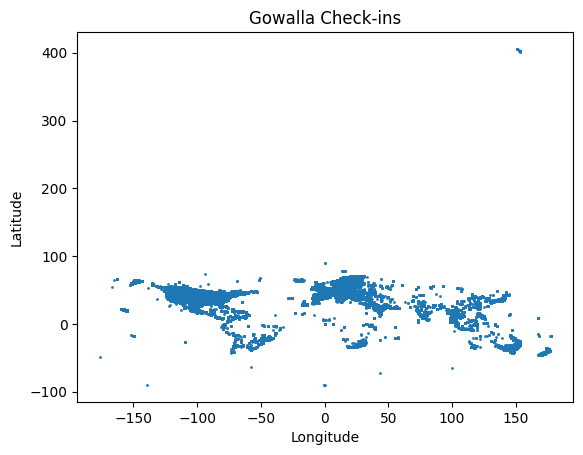

In [4]:
plt.scatter(df["longitude"], df["latitude"], s=1)
plt.title("Gowalla Check-ins")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

The data that we use contains Latitude and Longitude data. Since Latitude can only go up to 90 degrees both North and South, and Longitude only going up to 180 degrees West and East, values above this threshold are considered invalid and are removed.

Text(0, 0.5, 'Latitude')

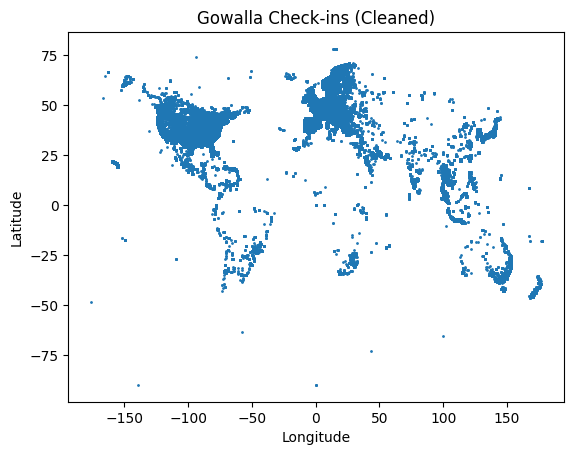

In [5]:
#Removing invalid data points
df = df.drop(df[df['latitude'] >= 90].index)
df = df.drop(df[df['longitude'] >= 180].index)
plt.scatter(df["longitude"], df["latitude"], s=1)
plt.title("Gowalla Check-ins (Cleaned)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

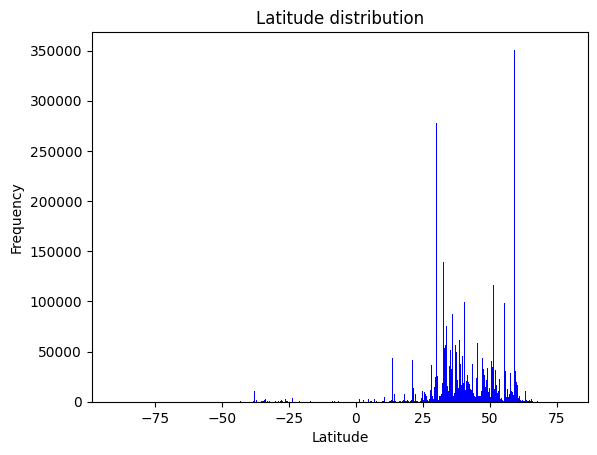

In [6]:
plt.figure()
plt.hist(df['latitude'], bins=1000, color="blue")
plt.title("Latitude distribution")
plt.xlabel("Latitude")
plt.ylabel("Frequency")
plt.show()

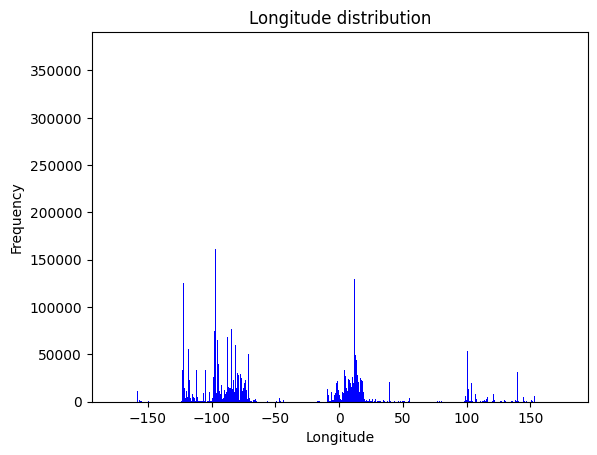

In [7]:
plt.figure()
plt.hist(df['longitude'], bins=1000, color="blue")
plt.title("Longitude distribution")
plt.xlabel("Longitude")
plt.ylabel("Frequency")
plt.show()

In [8]:
coordinates = list(zip(df['latitude'], df['longitude']))
result = rg.search(coordinates)

df["country_code"] = [result[i]['cc'] for i in range(len(result))]
df["country_code"] = df["country_code"].str.lower() #for pygal

cc = coco.CountryConverter()

mapping = {
    code: cc.convert(code, to="name")
    for code in df["country_code"].unique()
}

continent = {
    code: cc.convert(code, to="continent_7")
    for code in df["country_code"].unique()
}

df["country_name"] = df["country_code"].map(mapping)
df["continent"] = df["country_code"].map(continent)
df.to_csv('data/loc-gowalla-preproc.csv', index=False)
print(df.head())
print(df.tail())

Loading formatted geocoded file...
   user_id          checkin_time   latitude  longitude  location_id  \
0        0  2010-10-19T23:55:27Z  30.235909 -97.795140        22847   
1        0  2010-10-18T22:17:43Z  30.269103 -97.749395       420315   
2        0  2010-10-17T23:42:03Z  30.255731 -97.763386       316637   
3        0  2010-10-17T19:26:05Z  30.263418 -97.757597        16516   
4        0  2010-10-16T18:50:42Z  30.274292 -97.740523      5535878   

  country_code   country_name      continent  
0           us  United States  North America  
1           us  United States  North America  
2           us  United States  North America  
3           us  United States  North America  
4           us  United States  North America  
         user_id          checkin_time   latitude  longitude  location_id  \
6442887   196578  2010-06-11T13:32:26Z  51.742988  -0.488065       906885   
6442888   196578  2010-06-11T13:26:45Z  51.746492  -0.490780       965121   
6442889   196578  2010-06

In [9]:
country_counts = df["country_name"].value_counts().to_dict()
print(tabulate(country_counts.items(), headers=["Country Code", "Check-in Count"]))

Country Code                            Check-in Count
------------------------------------  ----------------
United States                                  3615082
Sweden                                          926787
Germany                                         349897
United Kingdom                                  272881
Norway                                          154534
Canada                                          129009
Netherlands                                      76617
Saudi Arabia                                     75109
Thailand                                         69777
Belgium                                          68834
Australia                                        64235
Switzerland                                      58648
Japan                                            51159
Puerto Rico                                      35145
France                                           34509
Spain                                            34123
Czechia   

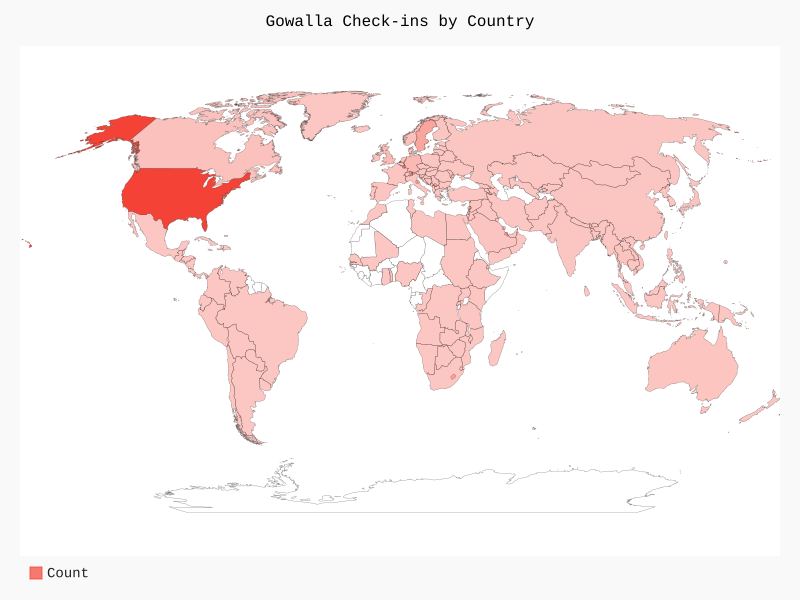

In [10]:
# Visualize the distribution of check-ins per country using a world map
count_country = df["country_code"].value_counts().to_dict()
worldmap = World()
worldmap.title = "Gowalla Check-ins by Country"
worldmap.add('Count', {
    country_code: count for country_code, count in count_country.items() if country_code is not None
})

SVG(worldmap.render(legend_at_bottom=True))


Clustering with DBSCAN one country at a time and comparison. (https://geoffboeing.com/2014/08/clustering-to-reduce-spatial-data-set-size/)
The UK:

## 2. Module 1 — Vector-Space Analysis

### 2.1 Vector Representation

Explain your feature construction and distance measure here.

### 2.2 Clustering Method

The next clustering algorithm we will be analysing is Agglomerative Clustering. Since we are working with geospatial data this means that our data has an inherently hierarchical structure: neighbourhoods, cities, and countries. Thus, agglomerative clustering seems like a natural fit for an algorithm that could work well within these hierarchies as well as model real boundaries of cities. We will start off with examining our main two focus points, the US and Europe. We will be working with samples made out of 50000 points due to technical limitationsa and memory issues.

In [4]:
BASE_DIR = Path().resolve()
file_path = BASE_DIR / "data" / "loc-gowalla-preproc.csv"
df_cluster = pd.read_csv(file_path)

Text(0, 0.5, 'Latitude')

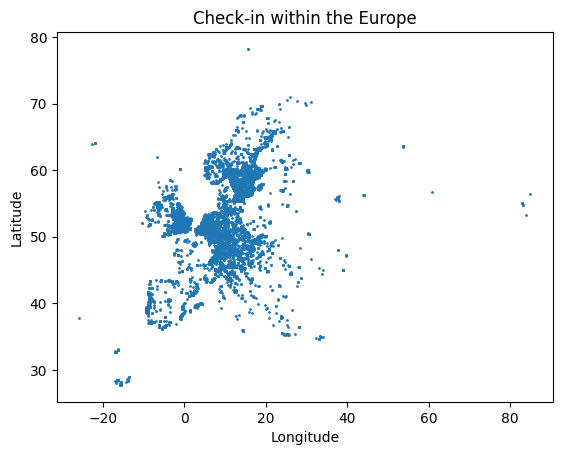

In [22]:
df_eu = df_cluster[df_cluster["continent"] == "Europe"].copy()
df_eu_sample = df_eu.sample(50_000, random_state=42)

plt.scatter(df_eu_sample["longitude"], df_eu_sample["latitude"], s=1)
plt.title("Check-in within the Europe")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

Text(0, 0.5, 'Latitude')

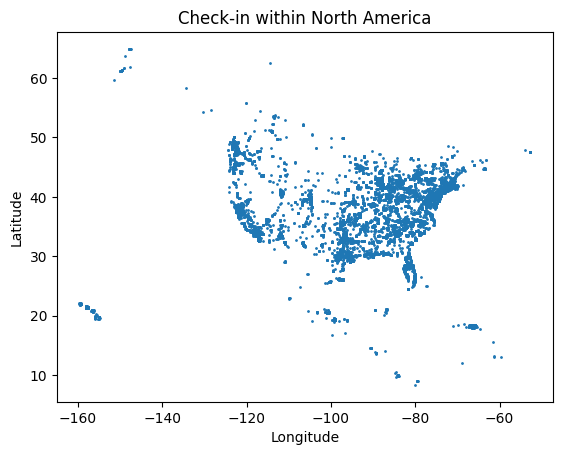

In [23]:
df_na = df_cluster[df_cluster["continent"] == "North America"].copy()
df_na_sample = df_na.sample(50_000, random_state=42)

plt.scatter(df_na_sample["longitude"], df_na_sample["latitude"], s=1)
plt.title("Check-in within North America")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

The agglomerative clustering function takes as input the data frame and performs the clustering algorithm and plots the results. In this way we will analyze and perform the hierarchical clustering on a few different scales, starting from the continents themselves, then taking by country/state and finally by city. 

In [7]:
def agglomerative_cluster(df, n_clusters=10, title="Agglomerative Clustering"):
    X = df[["latitude", "longitude"]].values
    X_scaled = StandardScaler().fit_transform(X)

    labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(X_scaled)

    df_plot = df.copy()
    df_plot["cluster"] = labels

    plt.figure(figsize=(10, 8))
    plt.scatter(
        df_plot["longitude"], df_plot["latitude"],
        c=df_plot["cluster"], cmap="tab20", s=2, alpha=0.6
    )
    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()
    
    return df_plot

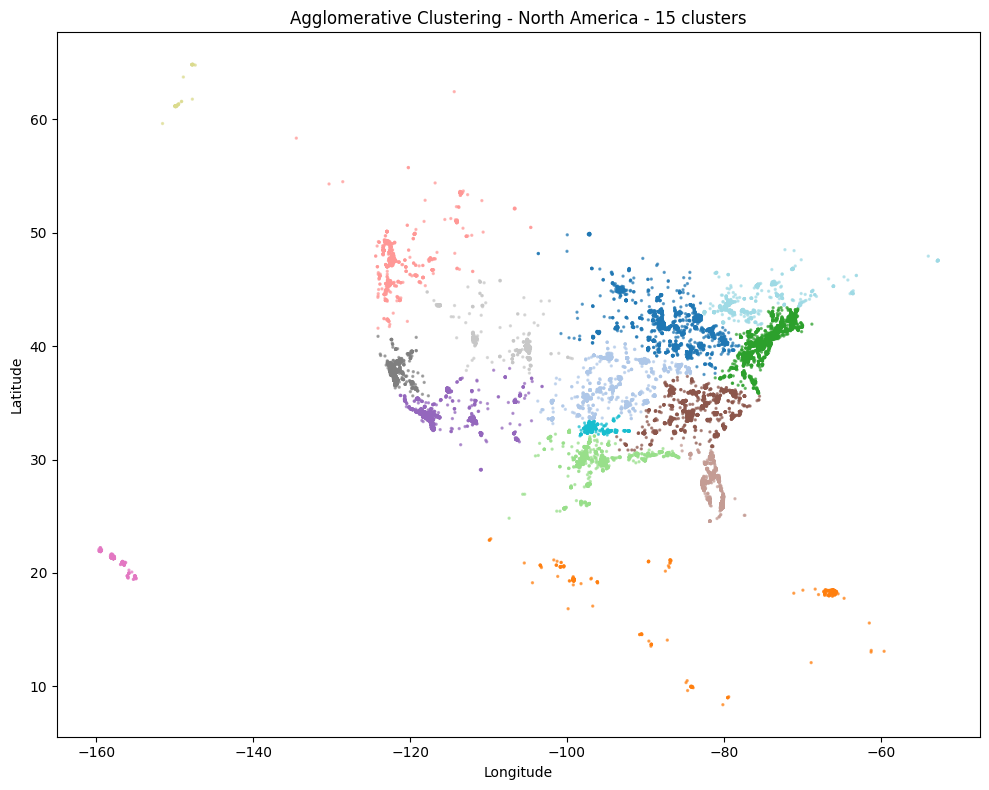

,user_id,checkin_time,latitude,longitude,location_id,country_code,country_name,continent,cluster
3306868,44394,2010-07-05T15:10:44Z,32.722576,-97.356774,369505,us,United States,North America,13
281764,898,2010-10-21T01:41:10Z,37.323592,-121.935024,85908,us,United States,North America,10
141002,458,2010-02-25T19:06:17Z,34.051379,-118.256632,345963,us,United States,North America,6
5281867,118624,2010-01-17T15:10:45Z,39.020773,-94.838268,401469,us,United States,North America,1
623205,2646,2010-06-27T18:10:00Z,29.742455,-95.411298,83062,us,United States,North America,4
...,...,...,...,...,...,...,...,...,...
1181047,5654,2010-08-17T01:25:02Z,30.265736,-97.737913,444277,us,United States,North America,4
295870,948,2010-07-15T02:43:51Z,42.524375,-88.985084,1366283,us,United States,North America,0
550310,2237,2010-08-14T19:50:49Z,33.813949,-117.924692,67957,us,United States,North America,6
4313798,90292,2010-04-19T00:13:25Z,30.162355,-97.790540,3475086,us,United States,North America,4


In [42]:
agglomerative_cluster(df_na_sample, 15, "Agglomerative Clustering - North America - 15 clusters")

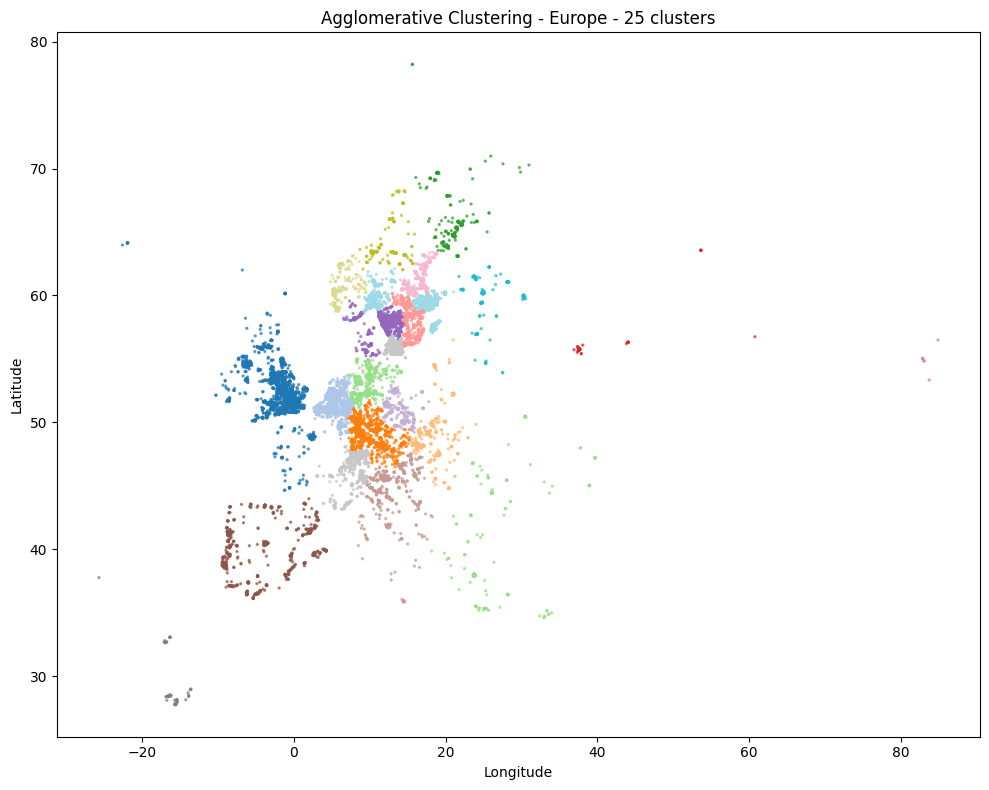

,user_id,checkin_time,latitude,longitude,location_id,country_code,country_name,continent,cluster
2348902,21796,2010-09-19T07:31:30Z,59.332024,18.055719,79394,se,Sweden,Europe,23
3867240,63146,2010-01-30T12:47:33Z,55.689085,13.220179,103171,se,Sweden,Europe,18
4248373,87092,2010-08-09T13:40:43Z,59.331170,18.042193,425819,se,Sweden,Europe,23
2992699,38404,2010-04-06T05:20:35Z,59.927308,10.731615,277191,no,Norway,Europe,24
4855366,107553,2010-07-02T19:38:51Z,62.047741,17.248329,1374392,se,Sweden,Europe,16
...,...,...,...,...,...,...,...,...,...
1204900,5864,2009-12-23T14:04:03Z,55.716028,13.179957,58891,se,Sweden,Europe,18
2971283,38201,2010-05-05T10:36:35Z,52.069979,5.178071,45094,nl,Netherlands,Europe,2
4280608,89035,2010-08-08T08:46:00Z,51.499126,-0.298058,30385,gb,United Kingdom,Europe,0
4259520,87690,2010-03-24T15:40:19Z,56.674450,12.856450,282285,se,Sweden,Europe,18


In [46]:
agglomerative_cluster(df_eu_sample, 25, "Agglomerative Clustering - Europe - 25 clusters")

After experimentation with the cluster numbers for both the North America and Europe regions, clusters of sizes 15 and 25, respectively, were picked. It can already be observed the forming of big metropolitan areas. When looking at North America, the biggest clusters correspond with the most dense areas, so California on the west coast and NYC on the east coast. The Chicago area is also easily identifiable as a big cluster, as is Florida as a separate one. A very clear and easy distinction can be made between the states, and of course the biggest hubs are on the coast versus the sparsity inland. In the major inland areas, there are large empty spatial gaps between clusters corresponding with just sparsely populated areas where deserts and prairies are located.

Similar observations can be made when looking at Europe. European cities are more tightly packed, and so are the clusters; thus, more clusters are necessary in order to capture better boundaries of countries. Immediately a big cluster jumps out, the UK London area, as a big metropolitan area, following Paris and Berlin. In the centre the distinction between countries is clearer; for example, Spain is easily distinguishable as one big cluster, as is the UK. There is also a small separation observable between the boundaries of Germany and the Netherlands. Sparser areas of population, however, have more multiple small clusters, observed very well in the Scandinavian area. When looking at Sweden, it is a very big territory with less population density; thus, we can see it being separated into multiple smaller clusters in comparison with the UK, a small area with large population density, being grouped as one big cluster.

Next, we will examine a smaller scale and verify if similar patterns emerge. For this purpose, we will look at the UK and Sweden in Europe.

Text(0, 0.5, 'Latitude')

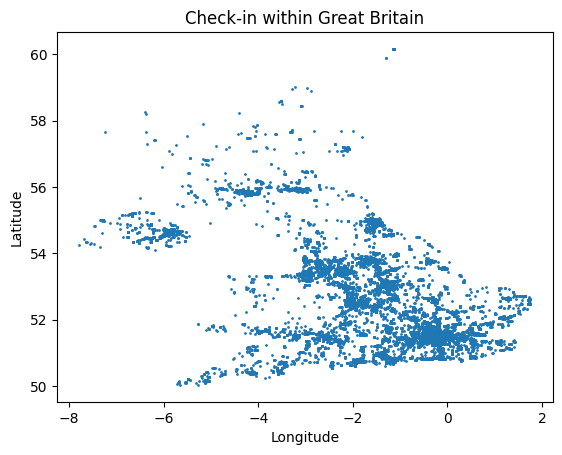

In [47]:
df_gb = df_cluster[df_cluster["country_code"] == "gb"].copy()
df_gb_sample = df_gb.sample(50_000, random_state=42)

plt.scatter(df_gb_sample["longitude"], df_gb_sample["latitude"], s=1)
plt.title("Check-in within Great Britain")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

Text(0, 0.5, 'Latitude')

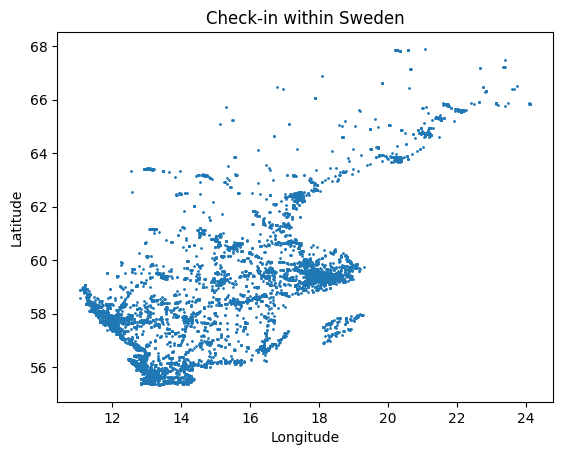

In [11]:
df_se = df_cluster[df_cluster["country_code"] == "se"].copy()
df_se_sample = df_se.sample(50_000, random_state=42)

plt.scatter(df_se_sample["longitude"], df_se_sample["latitude"], s=1)
plt.title("Check-in within Sweden")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

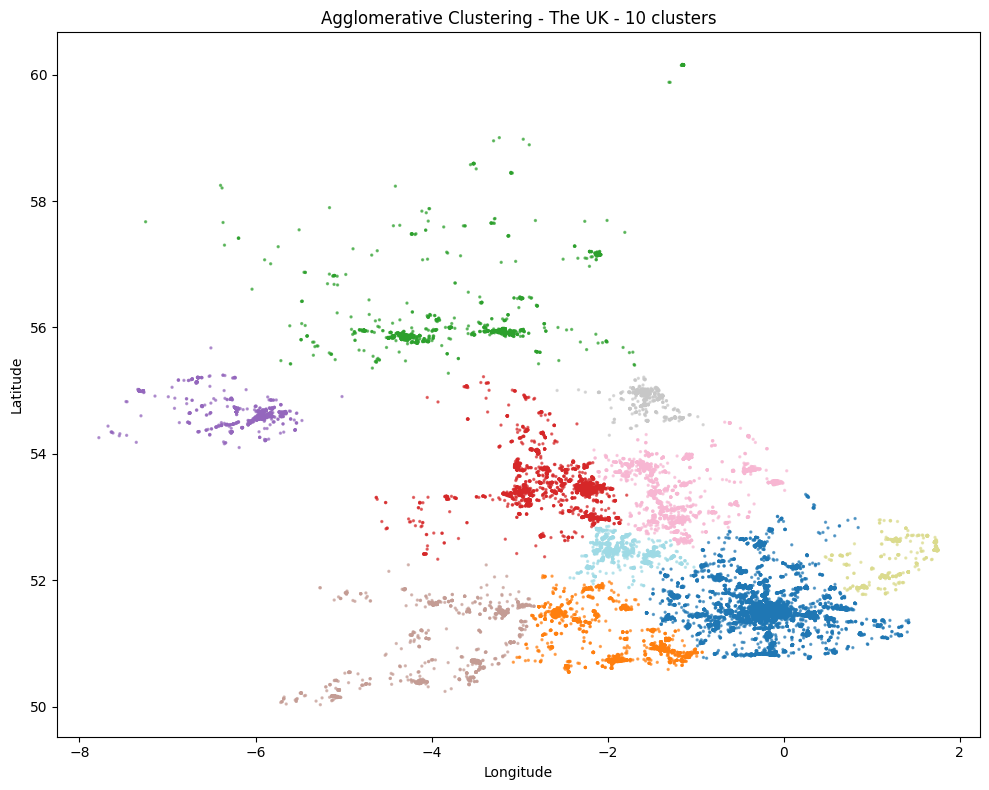

,user_id,checkin_time,latitude,longitude,location_id,country_code,country_name,continent,cluster
3496789,49352,2010-07-21T12:34:30Z,51.802264,-0.194523,666188,gb,United Kingdom,Europe,0
4614158,103183,2010-08-28T21:24:15Z,53.721233,-1.865050,1255579,gb,United Kingdom,Europe,6
5347377,120763,2010-02-04T09:49:07Z,53.794425,-1.543078,263293,gb,United Kingdom,Europe,6
971749,4508,2010-08-31T13:10:57Z,51.061968,-1.311463,1527091,gb,United Kingdom,Europe,1
2993227,38409,2010-04-06T07:28:50Z,51.528589,-0.132156,858505,gb,United Kingdom,Europe,0
...,...,...,...,...,...,...,...,...,...
1914134,15507,2010-07-22T09:05:34Z,51.494504,-0.274658,762275,gb,United Kingdom,Europe,0
2502539,26185,2009-12-15T11:15:34Z,55.832987,-4.428788,186917,gb,United Kingdom,Europe,2
5065684,111971,2010-05-23T12:31:34Z,51.597272,-2.981621,883463,gb,United Kingdom,Europe,5
3587945,51792,2010-02-17T11:00:42Z,50.788457,-1.082536,465712,gb,United Kingdom,Europe,1


In [52]:
agglomerative_cluster(df_gb_sample, 10, "Agglomerative Clustering - The UK - 10 clusters")

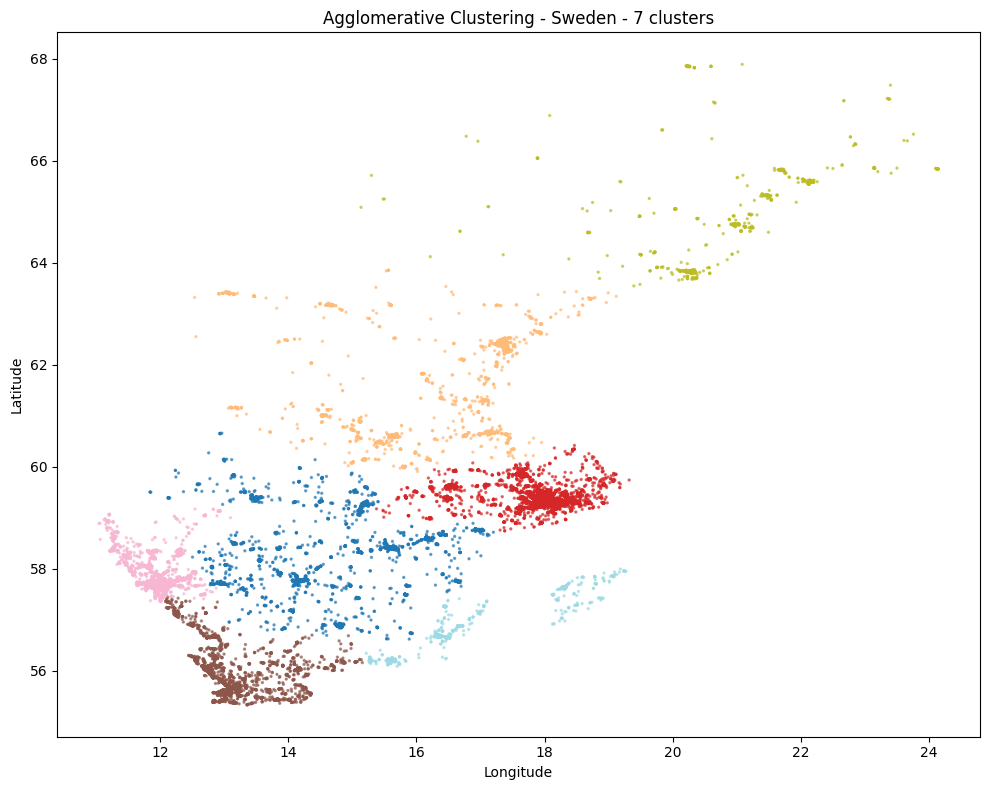

,user_id,checkin_time,latitude,longitude,location_id,country_code,country_name,continent,cluster
3670416,54996,2010-01-05T08:52:40Z,57.714698,11.966850,124263,se,Sweden,Europe,4
4865535,107759,2010-09-05T18:26:49Z,57.991270,13.090957,1453674,se,Sweden,Europe,0
5700193,135467,2010-09-26T14:08:03Z,57.689243,12.013705,4485402,se,Sweden,Europe,4
6175510,166198,2010-05-19T11:50:26Z,59.311474,18.059109,888888,se,Sweden,Europe,2
5640444,132335,2010-03-18T10:08:09Z,59.299543,18.055290,572819,se,Sweden,Europe,2
...,...,...,...,...,...,...,...,...,...
4565806,102082,2010-06-24T15:47:36Z,55.695680,13.198174,301159,se,Sweden,Europe,3
6174623,166157,2010-03-07T14:26:06Z,59.614513,16.543887,212841,se,Sweden,Europe,2
6021757,153041,2010-03-19T11:53:39Z,59.346815,18.059162,322432,se,Sweden,Europe,2
6360152,185792,2010-09-01T09:11:33Z,57.686679,11.986091,484011,se,Sweden,Europe,4


In [12]:
agglomerative_cluster(df_se_sample, 7, "Agglomerative Clustering - Sweden - 7 clusters")

As expected, we see that the biggest clusters of user check-ins correspond clearly to the biggest cities/most populated regions. When looking at the scatterplot of the UK, we see clusters formed around the different regions of the UK: London, the Midlands, Scotland, and Wales. The biggest clusters are represented in central London and Brighton, in the Wales region, Manchester and Liverpool, Scotland is a sparser cluster all on its own; and another major cluster is Northern Ireland.

In contrast, Sweden is a much bigger country by area; however, it has less population density. We identify 3 big clusters, each corresponding to Stockholm, Gothenburg and Malmö. We have a few more clusters in the centre and sparser clusters covering very big areas where there is less population density. 

The UK has more mid-sized cities competing for clusters and thus making the selection of k have a bit more flexibility and allowing a bigger size of clusters, while Sweden has, in big part, 3 major cities where most of the population is concentrated, making the selection of k be more reduced to smaller values to allow for much cleaner results and boundaries.

## 3. Module 2 — Graph-Based Analysis

In [19]:
import networkx as nx

# Build graph
G = nx.Graph()

## 4. Module 3 — Pattern / Text Mining

In [20]:
# Pattern mining implementation
patterns = None

## 5. Final Synthesis and Reflection

- Key insights:
- Limitations:
- Revisions after feedback:
